In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from scipy.signal import find_peaks

In [13]:
lam400 = "#8200b5" # Hex color code for 400nm wavelength (violet)
lam500 = "#00ff92"  # Hex color code for 500nm wavelength (greenish)
lam600 = "#ffbe00" # Hex color code for 600nm wavelength (yellow)
lam700 = "#ff0000" # Hex color code for 700nm wavelength (red)

# https://academo.org/demos/wavelength-to-colour-relationship/

# Initial Rectangular Aperture Code

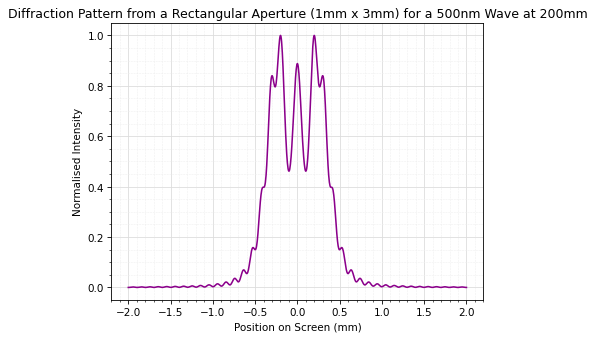

In [14]:
# Wave Equation and Properties

w, h = 1e-3, 3e-3 # Width and height of the aperture
L = 200e-3 # Distance from aperture to screen
lam = 500e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture (same as 2D)
nx, ny = 450, 1350 # Number of points in x and y
x_ap = np.linspace(-w/2, w/2, nx)
y_ap = np.linspace(-h/2, h/2, ny)

xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

aperture_points = np.stack((xx_ap.ravel(), yy_ap.ravel()), axis=-1)  # List of (x,y) points in the aperture

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

# Defining a Screen
screen = np.linspace(-2e-3, 2e-3, 1000)  # Screen from -5mm to 5mm

# Defining the Wave Equation

I = [] # List to hold the resultant field values at each point on the screen (intensity)
for x in screen:
    r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
    E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
    E_total = E.sum()  # Total electric field
    I.append(np.abs(E_total)**2)  # Intensity is proportional to the square of the electric field amplitude 

I = np.array(I)  # Convert list to array for easier plotting
I /= I.max()  # Normalize intensity for plotting

# Plotting the Intensity Pattern
plt.title('Diffraction Pattern from a Rectangular Aperture (1mm x 3mm) for a 500nm Wave at 200mm')
plt.xlabel('Position on Screen (mm)')
plt.ylabel('Normalised Intensity')

plt.plot(screen * 1e3, I, color='darkmagenta', linewidth=1.5)

plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()


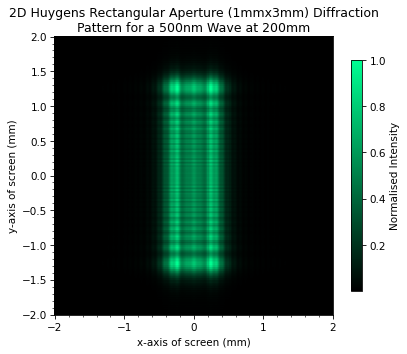

In [15]:
# Parameters
lam = 400e-9
k = 2*np.pi/lam
w, h = 1e-3, 3e-3
L = 200e-3

# Aperture sampling (Point sources)
nx, ny = 300, 900
x_ap = np.linspace(-w/2, w/2, nx)
y_ap = np.linspace(-h/2, h/2, ny)

xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

mask = (np.abs(xx_ap) <= w/2) & (np.abs(yy_ap) <= h/2)  # True for points inside the rectangle
xx_ap_rect = xx_ap[mask].ravel()
yy_ap_rect = yy_ap[mask].ravel()

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

aperture_points = np.stack((xx_ap_rect, yy_ap_rect), axis=-1)  # Creating a list of (x,y) points in the aperture

# Screen coordinates (2D)
screen_x1, screen_x2 = -2e-3, 2e-3
screen_y1, screen_y2 = -2e-3, 2e-3
screen_res = 1.5e-5 # Step size of screen grid

n = int((screen_x2 - screen_x1) / screen_res)
m = int((screen_y2 - screen_y1) / screen_res)

X = np.linspace(screen_x1, screen_x2, n)
Y = np.linspace(screen_y1, screen_y2, m)
X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

# Vectorized Huygens-Fresnel calculation
E_total = np.zeros((m, n), dtype=complex)
for ap in aperture_points:
    r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
    E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

I = np.abs(E_total)**2
I /= I.max()

# Plot the 2D diffraction pattern
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_aspect('equal')
plt.xlabel("x-axis of screen (mm)")
plt.ylabel("y-axis of screen (mm)")

plt.title("2D Huygens Rectangular Aperture (1mmx3mm) Diffraction Pattern for a 500nm Wave at 200mm", loc='center' , wrap=True)
graph = plt.pcolormesh(X*1e3, Y*1e3, I, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black',lam500]))
plt.colorbar(graph, orientation='vertical', label='Normalised Intensity', shrink=0.8)

plt.minorticks_on()

plt.show()

# much of the above used the link below as a guide:
# https://www.geeksforgeeks.org/python/single-slit-diffraction-pattern-using-python/


# Double Graph

## 400nm wave at 200mm with aperture 1mmx3mm

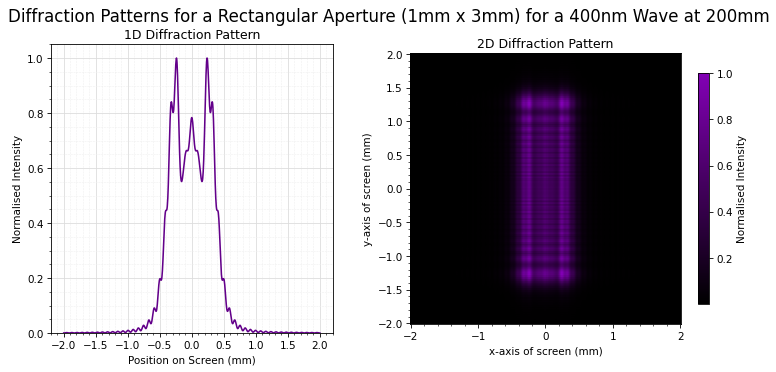

In [16]:
# Wave Equation and Properties

w, h = 1e-3, 3e-3 # Width and height of the aperture
L = 200e-3 # Distance from aperture to screen
lam = 400e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture (same as 2D)
nx, ny = 300, 900 # Number of points in x and y
x_ap = np.linspace(-w/2, w/2, nx)
y_ap = np.linspace(-h/2, h/2, ny)

xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

aperture_points = np.stack((xx_ap.ravel(), yy_ap.ravel()), axis=-1)  # List of (x,y) points in the aperture

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

# Defining the Wave Equation Functions for 1D and 2D

def rect_1d(screen=(-2e-3, 2e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def rect_2d(screen=(-2e-3, 2e-3), res=1.5e-5):

    screen_x1, screen_x2 = screen
    screen_y1, screen_y2 = screen
    n = int((screen_x2 - screen_x1) / res)
    m = int((screen_y2 - screen_y1) / res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I


# Plots
screen, I1D = rect_1d()
X, Y, I2D = rect_2d()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Patterns for a Rectangular Aperture (1mm x 3mm) for a 400nm Wave at 200mm', fontsize=16)

# 1D Plot
ax1.plot(screen * 1e3, I1D, color="#63008a", linewidth=1.5)
ax1.set_title('1D Diffraction Pattern')
ax1.set_xlabel('Position on Screen (mm)')
ax1.set_ylabel('Normalised Intensity')
ax1.set_ylim([0, 1.05])
ax1.minorticks_on()
ax1.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax1.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

# 2D Plot
graph = plt.pcolormesh(X*1e3, Y*1e3, I2D, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black',lam400]))
ax2.set_aspect('equal')
ax2.set_title('2D Diffraction Pattern')
ax2.set_xlabel("x-axis of screen (mm)")
ax2.set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=ax2, orientation='vertical', label='Normalised Intensity', shrink=0.8)
ax2.minorticks_on()

plt.subplots_adjust(wspace=0.25)

plt.show()


## 500nm wave at 200mm with aperture 1mmx3mm

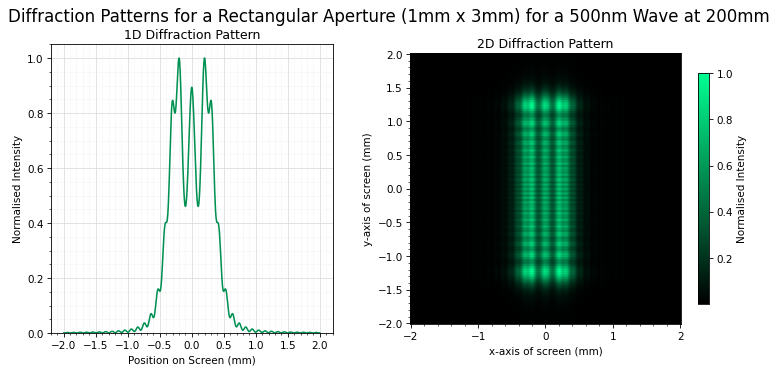

In [17]:
# Wave Equation and Properties

w, h = 1e-3, 3e-3 # Width and height of the aperture
L = 200e-3 # Distance from aperture to screen
lam = 500e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture (same as 2D)
nx, ny = 300, 900 # Number of points in x and y
x_ap = np.linspace(-w/2, w/2, nx)
y_ap = np.linspace(-h/2, h/2, ny)

xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

aperture_points = np.stack((xx_ap.ravel(), yy_ap.ravel()), axis=-1)  # List of (x,y) points in the aperture

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

# Defining the Wave Equation Functions for 1D and 2D

def rect_1d(screen=(-2e-3, 2e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def rect_2d(screen=(-2e-3, 2e-3), res=1.5e-5):

    screen_x1, screen_x2 = screen
    screen_y1, screen_y2 = screen
    n = int((screen_x2 - screen_x1) / res)
    m = int((screen_y2 - screen_y1) / res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I


# Plots
screen, I1D = rect_1d()
X, Y, I2D = rect_2d()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Patterns for a Rectangular Aperture (1mm x 3mm) for a 500nm Wave at 200mm', fontsize=16)

# 1D Plot
ax1.plot(screen * 1e3, I1D, color='#009152', linewidth=1.5)
ax1.set_title('1D Diffraction Pattern')
ax1.set_xlabel('Position on Screen (mm)')
ax1.set_ylabel('Normalised Intensity')
ax1.set_ylim([0, 1.05])
ax1.minorticks_on()
ax1.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax1.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

# 2D Plot
graph = plt.pcolormesh(X*1e3, Y*1e3, I2D, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black',lam500]))
ax2.set_aspect('equal')
ax2.set_title('2D Diffraction Pattern')
ax2.set_xlabel("x-axis of screen (mm)")
ax2.set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=ax2, orientation='vertical', label='Normalised Intensity', shrink=0.8)
ax2.minorticks_on()

plt.subplots_adjust(wspace=0.25)

plt.show()


## 600nm wave at 200mm with aperture 1mmx3mm

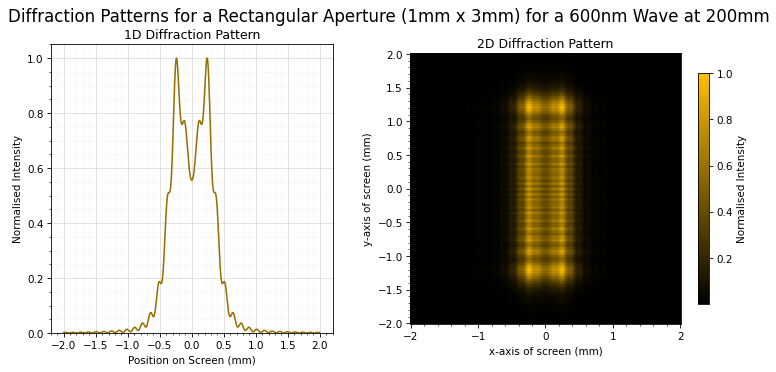

In [18]:
# Wave Equation and Properties

w, h = 1e-3, 3e-3 # Width and height of the aperture
L = 200e-3 # Distance from aperture to screen
lam = 600e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture (same as 2D)
nx, ny = 300, 900 # Number of points in x and y
x_ap = np.linspace(-w/2, w/2, nx)
y_ap = np.linspace(-h/2, h/2, ny)

xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

aperture_points = np.stack((xx_ap.ravel(), yy_ap.ravel()), axis=-1)  # List of (x,y) points in the aperture

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

# Defining the Wave Equation Functions for 1D and 2D

def rect_1d(screen=(-2e-3, 2e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def rect_2d(screen=(-2e-3, 2e-3), res=1.5e-5):

    screen_x1, screen_x2 = screen
    screen_y1, screen_y2 = screen
    n = int((screen_x2 - screen_x1) / res)
    m = int((screen_y2 - screen_y1) / res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I


# Plots
screen, I1D = rect_1d()
X, Y, I2D = rect_2d()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Patterns for a Rectangular Aperture (1mm x 3mm) for a 600nm Wave at 200mm', fontsize=16)

# 1D Plot
ax1.plot(screen * 1e3, I1D, color='#967100', linewidth=1.5)
ax1.set_title('1D Diffraction Pattern')
ax1.set_xlabel('Position on Screen (mm)')
ax1.set_ylabel('Normalised Intensity')
ax1.set_ylim([0, 1.05])
ax1.minorticks_on()
ax1.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax1.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

# 2D Plot
graph = plt.pcolormesh(X*1e3, Y*1e3, I2D, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black',lam600]))
ax2.set_aspect('equal')
ax2.set_title('2D Diffraction Pattern')
ax2.set_xlabel("x-axis of screen (mm)")
ax2.set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=ax2, orientation='vertical', label='Normalised Intensity', shrink=0.8)
ax2.minorticks_on()

plt.subplots_adjust(wspace=0.25)

plt.show()


# Initial Circular Aperture Code

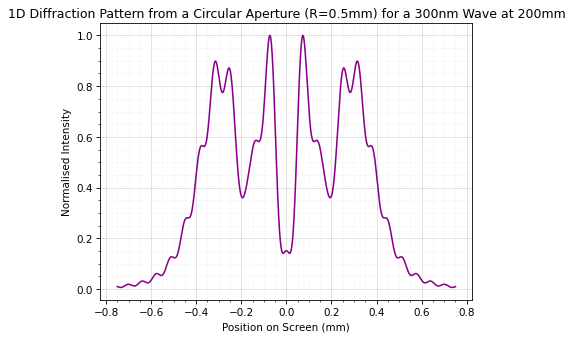

In [19]:
# Wave Equation and Properties

R = 0.5e-3 # Radius of circular aperture
w = h = 2 * R
L = 200e-3 # Distance from aperture to screen
lam = 300e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture (same as 2D)
nx, ny = 500, 500
x_ap = np.linspace(-w/2, w/2, nx)
y_ap = np.linspace(-h/2, h/2, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = xx_ap**2 + yy_ap**2 <= R**2 # Circular aperture mask

xx_ap_circ = xx_ap[mask].ravel()
yy_ap_circ = yy_ap[mask].ravel()
aperture_points = np.stack((xx_ap_circ, yy_ap_circ), axis=-1)  # List of (x,y) points in the aperture

# Defining a 1D Screen (same range as 2D)
screen = np.linspace(-0.75e-3, 0.75e-3, 2500)

I = [] # List to hold the resultant field values at each point on the screen (intensity)
for x in screen:
    r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
    E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
    E_total = E.sum()  # Total electric field
    I.append(np.abs(E_total)**2)  # Intensity is proportional to the square of the electric field amplitude 

I = np.array(I)  # Convert list to array for easier plotting
I /= I.max()  # Normalize intensity for plotting

# Plotting the Intensity Pattern
plt.title('1D Diffraction Pattern from a Circular Aperture (R=0.5mm) for a 300nm Wave at 200mm')
plt.xlabel('Position on Screen (mm)')
plt.ylabel('Normalised Intensity')

plt.plot(screen * 1e3, I, color='darkmagenta', linewidth=1.5)
plt.minorticks_on()
plt.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
plt.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

plt.show()


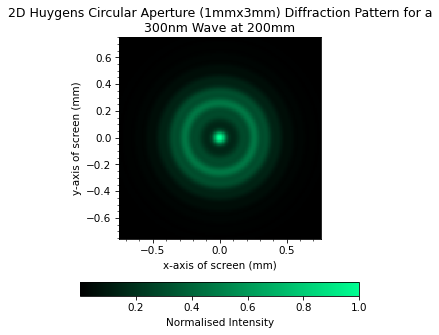

In [20]:
# Wave Equation and Properties

R = 0.5e-3 # Radius of circular aperture
w = h = 2 * R
L = 200e-3 # Distance from aperture to screen
lam = 400e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 1000, 1000
x_ap = np.linspace(-R, R, nx)
y_ap = np.linspace(-R, R, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = xx_ap**2 + yy_ap**2 <= R**2 # Circular aperture mask
xx_ap_circ = xx_ap[mask].ravel()
yy_ap_circ = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_circ, yy_ap_circ), axis=-1)  # Creating a list of (x,y) points in the aperture

# Screen coordinates (2D)
screen_x1, screen_x2 = -0.75e-3, 0.75e-3
screen_y1, screen_y2 = -0.75e-3, 0.75e-3
screen_res = 1e-5 # Step size of screen grid

n = int((screen_x2 - screen_x1) / screen_res)
m = int((screen_y2 - screen_y1) / screen_res)

X = np.linspace(screen_x1, screen_x2, n)
Y = np.linspace(screen_y1, screen_y2, m)
X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

# Vectorized Huygens-Fresnel calculation
E_total = np.zeros((m, n), dtype=complex)
for ap in aperture_points:
    r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
    E_total += (np.exp(1j * k * r) / r) * area

I = np.abs(E_total)**2
I /= I.max()

# Plot the 2D diffraction pattern
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_aspect('equal')
plt.xlabel("x-axis of screen (mm)")
plt.ylabel("y-axis of screen (mm)")

plt.title("2D Huygens Circular Aperture (1mmx3mm) Diffraction Pattern for a 300nm Wave at 200mm", loc='center' , wrap=True)
graph = plt.pcolormesh(X*1e3, Y*1e3, I, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black','#00ff92']))
plt.colorbar(graph, orientation='horizontal', label='Normalised Intensity', shrink=0.8)

plt.minorticks_on()

plt.show()



# Double Graph

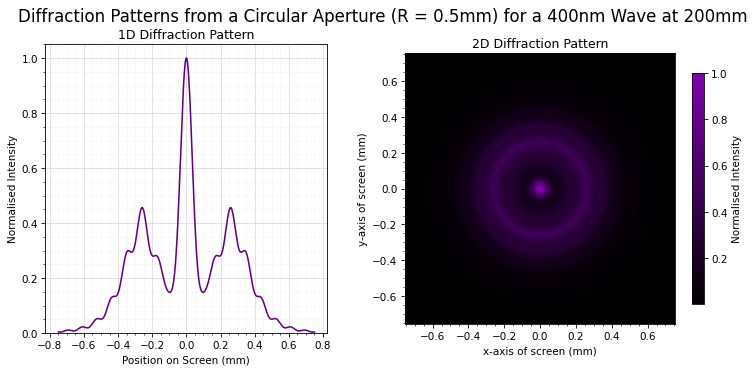

In [21]:
# Wave Equation and Properties

R = 0.5e-3 # Radius of circular aperture
w = h = 2 * R
L = 200e-3 # Distance from aperture to screen
lam = 400e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 1000, 1000
x_ap = np.linspace(-R, R, nx)
y_ap = np.linspace(-R, R, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = xx_ap**2 + yy_ap**2 <= R**2 # Circular aperture mask

xx_ap_circ = xx_ap[mask].ravel()
yy_ap_circ = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_circ, yy_ap_circ), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def circ_1d(screen=(-0.75e-3, 0.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def circ_2d(screen=(-0.75e-3, 0.75e-3), res=1.5e-5):

    screen_x1, screen_x2 = -0.75e-3, 0.75e-3
    screen_y1, screen_y2 = -0.75e-3, 0.75e-3
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Plots
screen, I1D = circ_1d()
X, Y, I2D = circ_2d()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Patterns from a Circular Aperture (R = 0.5mm) for a 400nm Wave at 200mm', fontsize=16)

# 1D Plot
ax1.plot(screen * 1e3, I1D, color='#63008a', linewidth=1.5)
ax1.set_title('1D Diffraction Pattern')
ax1.set_xlabel('Position on Screen (mm)')
ax1.set_ylabel('Normalised Intensity')
ax1.set_ylim([0, 1.05])
ax1.minorticks_on()
ax1.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax1.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

# 2D Plot
graph = plt.pcolormesh(X*1e3, Y*1e3, I2D, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black',lam400]))
ax2.set_aspect('equal')
ax2.set_title('2D Diffraction Pattern')
ax2.set_xlabel("x-axis of screen (mm)")
ax2.set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=ax2, orientation='vertical', label='Normalised Intensity', shrink=0.8)
ax2.minorticks_on()

plt.subplots_adjust(wspace=0.25)

plt.show()

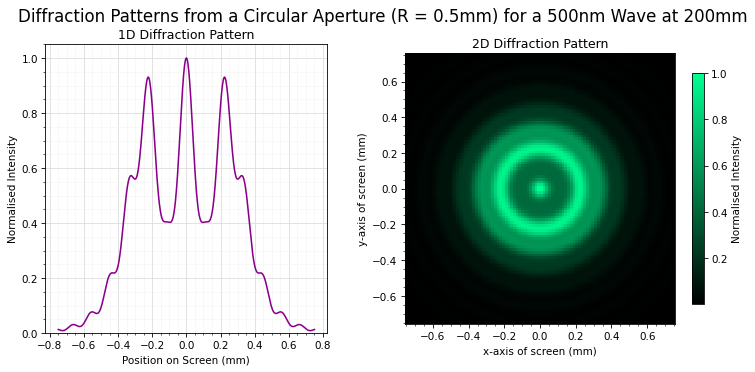

In [22]:
# Wave Equation and Properties

R = 0.5e-3 # Radius of circular aperture
w = h = 2 * R
L = 200e-3 # Distance from aperture to screen
lam = 500e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 1000, 1000
x_ap = np.linspace(-R, R, nx)
y_ap = np.linspace(-R, R, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = xx_ap**2 + yy_ap**2 <= R**2 # Circular aperture mask

xx_ap_circ = xx_ap[mask].ravel()
yy_ap_circ = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_circ, yy_ap_circ), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def circ_1d(screen=(-0.75e-3, 0.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def circ_2d(screen=(-0.75e-3, 0.75e-3), screen_res=1.5e-5):

    screen_x1, screen_x2 = -0.75e-3, 0.75e-3
    screen_y1, screen_y2 = -0.75e-3, 0.75e-3
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Plots
screen, I1D = circ_1d()
X, Y, I2D = circ_2d()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Patterns from a Circular Aperture (R = 0.5mm) for a 500nm Wave at 200mm', fontsize=16)

# 1D Plot
ax1.plot(screen * 1e3, I1D, color='darkmagenta', linewidth=1.5)
ax1.set_title('1D Diffraction Pattern')
ax1.set_xlabel('Position on Screen (mm)')
ax1.set_ylabel('Normalised Intensity')
ax1.set_ylim([0, 1.05])
ax1.minorticks_on()
ax1.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax1.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

# 2D Plot
graph = plt.pcolormesh(X*1e3, Y*1e3, I2D, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black',lam500]))
ax2.set_aspect('equal')
ax2.set_title('2D Diffraction Pattern')
ax2.set_xlabel("x-axis of screen (mm)")
ax2.set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=ax2, orientation='vertical', label='Normalised Intensity', shrink=0.8)
ax2.minorticks_on()

plt.subplots_adjust(wspace=0.25)

plt.show()

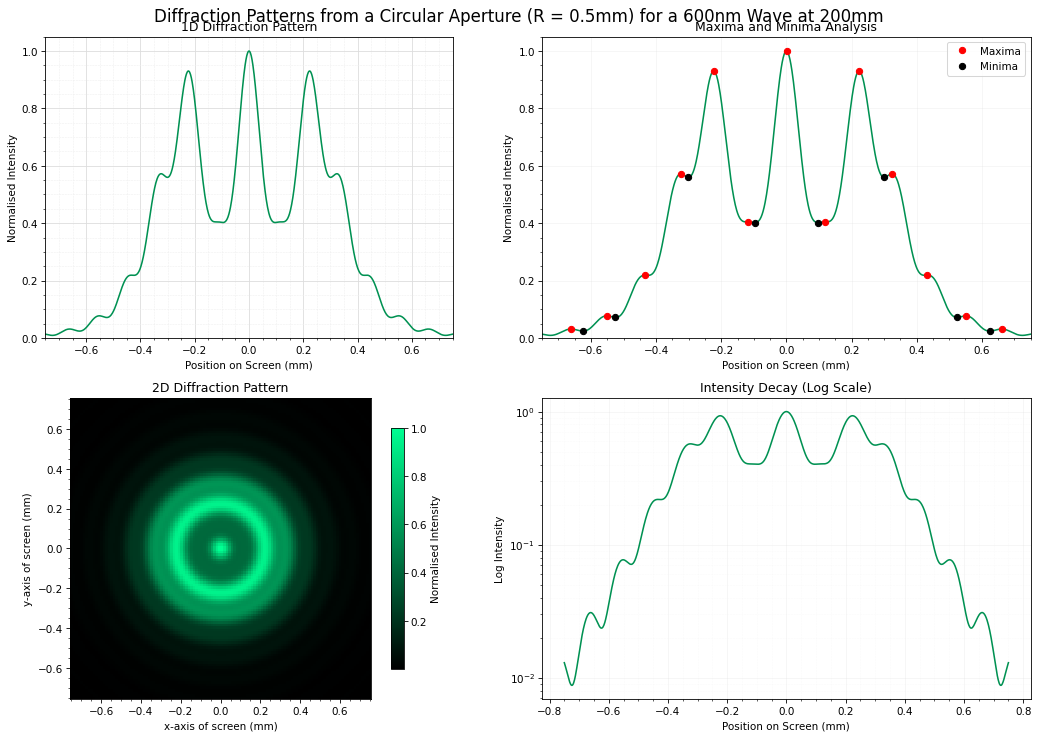

In [23]:
# Wave Equation and Properties

R = 0.5e-3 # Radius of circular aperture
w = h = 2 * R
L = 200e-3 # Distance from aperture to screen
lam = 500e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 1000, 1000
x_ap = np.linspace(-R, R, nx)
y_ap = np.linspace(-R, R, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = xx_ap**2 + yy_ap**2 <= R**2 # Circular aperture mask

xx_ap_circ = xx_ap[mask].ravel()
yy_ap_circ = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_circ, yy_ap_circ), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def circ_1d(screen=(-0.75e-3, 0.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / L) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def circ_2d(screen=(-0.75e-3, 0.75e-3), screen_res=1.25e-5):

    screen_x1, screen_x2 = -0.75e-3, 0.75e-3
    screen_y1, screen_y2 = -0.75e-3, 0.75e-3
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / L) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Patterns
screen, I1D = circ_1d()
X, Y, I2D = circ_2d(screen_res=1.25e-5)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Patterns from a Circular Aperture (R = 0.5mm) for a 600nm Wave at 200mm', fontsize=16)

# 1D Plot; top left
axes[0,0].plot(screen * 1e3, I1D, color='#009152', linewidth=1.5)
axes[0,0].set_title('1D Diffraction Pattern')
axes[0,0].set_xlabel('Position on Screen (mm)')
axes[0,0].set_ylabel('Normalised Intensity')
axes[0,0].set_ylim([0, 1.05])
axes[0,0].set_xlim([-0.75, 0.75])
axes[0,0].minorticks_on()
axes[0,0].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,0].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

# 2D Plotl; bottom left
graph = axes[1,0].pcolormesh(X*1e3, Y*1e3, I2D, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black',lam500]))
axes[1,0].set_aspect('equal')
axes[1,0].set_title('2D Diffraction Pattern')
axes[1,0].set_xlabel("x-axis of screen (mm)")
axes[1,0].set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=axes[1,0], orientation='vertical', label='Normalised Intensity', shrink=0.8)
axes[1,0].minorticks_on()

# Peak and Valley Slices; top right
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks
peaks, _ = find_peaks(I1D, height=0.01)
valleys, _ = find_peaks(-I1D, prominence=0.005)

axes[0,1].plot(screen * 1e3, I1D, color='#009152', linewidth=1.5)
axes[0,1].plot(screen[peaks] * 1e3, I1D[peaks], "ro", label='Maxima')
axes[0,1].plot(screen[valleys] * 1e3, I1D[valleys], "ko", label='Minima')
axes[0,1].set_title('Maxima and Minima Analysis')
axes[0,1].set_xlabel('Position on Screen (mm)')
axes[0,1].set_ylabel('Normalised Intensity')
axes[0,1].set_ylim([0, 1.05])
axes[0,1].set_xlim([-0.75, 0.75])
axes[0,1].grid(True, alpha=0.3, color="#DDDDDD")
axes[0,1].minorticks_on()
axes[0,1].legend(loc='upper right')

# Peak Information text
if len(peaks) > 1:
    central_peak = I1D[peaks[0]]
    first_ring_peak = I1D[peaks[1]]

# Intensity Decay Log Plot; bottom right
mask = I1D > 1e-12

axes[1,1].plot(screen * 1e3, I1D[mask], color='#009152', linewidth=1.5)
axes[1,1].set_yscale('log')
axes[1,1].set_title('Intensity Decay (Log Scale)')
axes[1,1].set_xlabel('Position on Screen (mm)')
axes[1,1].set_ylabel('Log Intensity')

axes[1,1].grid(True, which="both", linewidth=0.3, color="#DDDDDD", zorder=2, alpha=0.3)
axes[1,1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[1,1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[1,1].minorticks_on()

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, top=0.94)

plt.show()

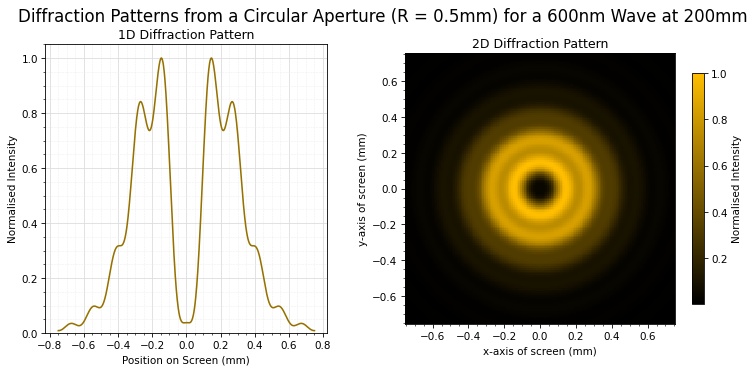

lambda=600 nm: N_F=2.0833, aR^2=6.5450 rad, |E_on|_analytic (arb)=4.9857e-09
lambda=500 nm: N_F=2.5000, aR^2=7.8540 rad, |E_on|_analytic (arb)=2.2508e-08
lambda=400 nm: N_F=3.1250, aR^2=9.8175 rad, |E_on|_analytic (arb)=2.4975e-08


In [24]:
# Wave Equation and Properties

R = 0.5e-3 # Radius of circular aperture
w = h = 2 * R
L = 200e-3 # Distance from aperture to screen
lam = 600e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 1000, 1000
x_ap = np.linspace(-R, R, nx)
y_ap = np.linspace(-R, R, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = xx_ap**2 + yy_ap**2 <= R**2 # Circular aperture mask

xx_ap_circ = xx_ap[mask].ravel()
yy_ap_circ = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_circ, yy_ap_circ), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def circ_1d(screen=(-0.75e-3, 0.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def circ_2d(screen=(-0.75e-3, 0.75e-3), res=1.5e-5):

    screen_x1, screen_x2 = -0.75e-3, 0.75e-3
    screen_y1, screen_y2 = -0.75e-3, 0.75e-3
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Plots
screen, I1D = circ_1d()
X, Y, I2D = circ_2d()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Patterns from a Circular Aperture (R = 0.5mm) for a 600nm Wave at 200mm', fontsize=16)

# 1D Plot
ax1.plot(screen * 1e3, I1D, color='#967100', linewidth=1.5)
ax1.set_title('1D Diffraction Pattern')
ax1.set_xlabel('Position on Screen (mm)')
ax1.set_ylabel('Normalised Intensity')
ax1.set_ylim([0, 1.05])
ax1.minorticks_on()
ax1.grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
ax1.grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

# 2D Plot
graph = plt.pcolormesh(X*1e3, Y*1e3, I2D, shading='auto',
                       cmap=matplotlib.colors.LinearSegmentedColormap.from_list("", ['black',lam600]))
ax2.set_aspect('equal')
ax2.set_title('2D Diffraction Pattern')
ax2.set_xlabel("x-axis of screen (mm)")
ax2.set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=ax2, orientation='vertical', label='Normalised Intensity', shrink=0.8)
ax2.minorticks_on()

plt.subplots_adjust(wspace=0.25)

plt.show()

R = 0.5e-3
L = 0.2
for lam in [600e-9, 500e-9, 400e-9]:
    NF = R**2 / (lam * L)
    a = np.pi / (lam * L)
    arg = a * R**2  # = pi * NF
    onaxis_analytic = np.abs((np.exp(1j*arg) - 1) / (2*a))  # proportional to |E(0)|
    print(f"lambda={lam*1e9:.0f} nm: N_F={NF:.4f}, aR^2={arg:.4f} rad, |E_on|_analytic (arb)={onaxis_analytic:.4e}") # Verifying for central maximum appearance

# Because I was going insane thinking my 600nm code was wrong
# It was the voices of insecurity :( 


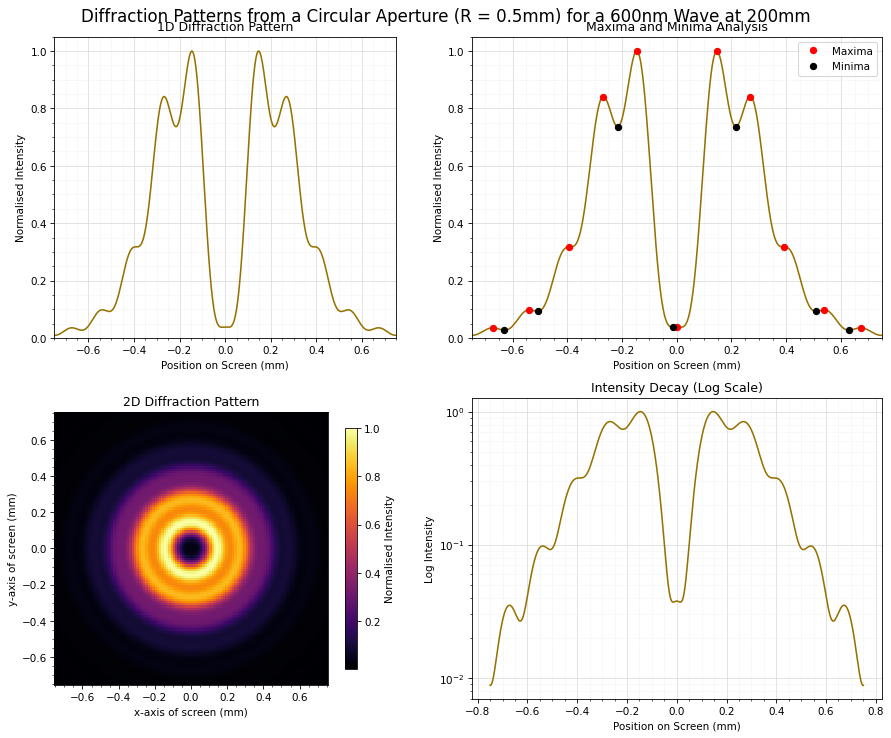

In [26]:
# Wave Equation and Properties

R = 0.5e-3 # Radius of circular aperture
w = h = 2 * R
L = 200e-3 # Distance from aperture to screen
lam = 600e-9 # Wavelengths of light 

k = 2 * np.pi / lam  # Wave number/vector

# Defining Aperture
nx, ny = 1000, 1000
x_ap = np.linspace(-R, R, nx)
y_ap = np.linspace(-R, R, ny)
xx_ap, yy_ap = np.meshgrid(x_ap, y_ap)

dx = x_ap[1] - x_ap[0]
dy = y_ap[1] - y_ap[0] # Spacing between points in the aperture grid
area = dx * dy # Area of each point source in the aperture (Riemann sum element)

mask = xx_ap**2 + yy_ap**2 <= R**2 # Circular aperture mask

xx_ap_circ = xx_ap[mask].ravel()
yy_ap_circ = yy_ap[mask].ravel() # Flattening the arrays to 1D for easier computation 

aperture_points = np.stack((xx_ap_circ, yy_ap_circ), axis=-1)  # Creating a list of (x,y) points in the aperture

# Defining the Wave Equation Functions for 1D and 2D

def circ_1d(screen=(-0.75e-3, 0.75e-3), points=1000):

    screen = np.linspace(screen[0], screen[1], points)  # Screen

    I = [] # List to hold the resultant field values at each point on the screen (intensity)
    for x in screen:
        r = np.sqrt((x - aperture_points[:,0])**2 + (aperture_points[:,1])**2 + L**2)
        E = (np.exp(1j * k * r) / r) * area  # Electric field at each point on the screen due to each point in the aperture
        E_total = E.sum()  # Total electric field
        I.append(np.abs(E_total)**2) 

    I = np.array(I)  # Convert list to array for easier plotting
    I /= I.max()  # Normalize intensity for plotting

    return screen, I

def circ_2d(screen=(-0.75e-3, 0.75e-3), screen_res=1.25e-5):

    screen_x1, screen_x2 = -0.75e-3, 0.75e-3
    screen_y1, screen_y2 = -0.75e-3, 0.75e-3
    n = int((screen_x2 - screen_x1) / screen_res)
    m = int((screen_y2 - screen_y1) / screen_res)

    X = np.linspace(screen_x1, screen_x2, n)
    Y = np.linspace(screen_y1, screen_y2, m)
    X, Y = np.meshgrid(X, Y)  # 2D grid of screen points

    E_total = np.zeros((m, n), dtype=complex)
    for ap in aperture_points:
        r = np.sqrt((X - ap[0])**2 + (Y - ap[1])**2 + L**2) # ap[0] and ap[1] are the x and y coordinates of the aperture point
        E_total += (np.exp(1j * k * r) / r) * area  # Sum contributions from each point source

    I = np.abs(E_total)**2
    I /= I.max()

    return X, Y, I

# Patterns
screen, I1D = circ_1d()
X, Y, I2D = circ_2d(screen_res=1.25e-5)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10), gridspec_kw={'width_ratios':[1, 1.2]})

fig.suptitle('Diffraction Patterns from a Circular Aperture (R = 0.5mm) for a 600nm Wave at 200mm', fontsize=16)

# 1D Plot; top left
axes[0,0].plot(screen * 1e3, I1D, color='#967100', linewidth=1.5)
axes[0,0].set_title('1D Diffraction Pattern')
axes[0,0].set_xlabel('Position on Screen (mm)')
axes[0,0].set_ylabel('Normalised Intensity')
axes[0,0].set_ylim([0, 1.05])
axes[0,0].set_xlim([-0.75, 0.75])
axes[0,0].minorticks_on()
axes[0,0].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,0].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)

# 2D Plotl; bottom left
graph = axes[1,0].pcolormesh(X*1e3, Y*1e3, I2D, shading='auto',
                       cmap='inferno')
axes[1,0].set_aspect('equal')
axes[1,0].set_title('2D Diffraction Pattern')
axes[1,0].set_xlabel("x-axis of screen (mm)")
axes[1,0].set_ylabel("y-axis of screen (mm)")
fig.colorbar(graph, ax=axes[1,0], orientation='vertical', label='Normalised Intensity', shrink=0.8)
axes[1,0].minorticks_on()

# Peak and Valley Slices; top right
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html#scipy.signal.find_peaks
peaks, _ = find_peaks(I1D, height=0.01)
valleys, _ = find_peaks(-I1D, prominence=0.005)

axes[0,1].plot(screen * 1e3, I1D, color='#967100', linewidth=1.5)
axes[0,1].plot(screen[peaks] * 1e3, I1D[peaks], "ro", label='Maxima')
axes[0,1].plot(screen[valleys] * 1e3, I1D[valleys], "ko", label='Minima')
axes[0,1].set_title('Maxima and Minima Analysis')
axes[0,1].set_xlabel('Position on Screen (mm)')
axes[0,1].set_ylabel('Normalised Intensity')
axes[0,1].set_ylim([0, 1.05])
axes[0,1].set_xlim([-0.75, 0.75])

axes[0,1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[0,1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[0,1].minorticks_on()
axes[0,1].legend(loc='upper right')

# Peak Information text
if len(peaks) > 1:
    central_peak = I1D[peaks[0]]
    first_ring_peak = I1D[peaks[1]]

# Intensity Decay Log Plot; bottom right
mask = I1D > 1e-12

axes[1,1].plot(screen * 1e3, I1D[mask], color='#967100', linewidth=1.5)
axes[1,1].set_yscale('log')
axes[1,1].set_title('Intensity Decay (Log Scale)')
axes[1,1].set_xlabel('Position on Screen (mm)')
axes[1,1].set_ylabel('Log Intensity')

axes[1,1].grid(True, which="major", linewidth=0.8, color="#DDDDDD", zorder=2)
axes[1,1].grid(True, which="minor", linewidth=0.5, color="#EEEEEE", linestyle="--", zorder=1)
axes[1,1].minorticks_on()

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, top=0.94)

plt.show()